<a href="https://colab.research.google.com/github/hasnanasa/machine-learning/blob/main/fairlearnproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install sentence-transformers
%pip install fairlearn==0.8.0
%pip install fairlearn.metrics

ERROR: Could not find a version that satisfies the requirement fairlearn.metrics (from versions: none)
ERROR: No matching distribution found for fairlearn.metrics


In [46]:
import pandas as pd

cvs = pd.read_csv('cvs.csv')
jobs = pd.read_csv('jobs.csv')

print("CVs:")
print(cvs.head())
print("\nJobs:")
print(jobs.head())

CVs:
   id                                              texte genre
0   1  Data scientist with 3 years experience in Pyth...     M
1   2  Software engineer skilled in Java, Spring Boot...     M
2   3  Marketing manager with expertise in digital ca...     F
3   4  Data analyst proficient in SQL, Excel, and Tab...     F
4   5  HR specialist with recruiting and employee rel...     F

Jobs:
    id                                        description
0  101  Looking for a data scientist with Python and M...
1  102  Need a software engineer proficient in Java an...
2  103  Seeking a marketing manager to lead digital ca...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Forme des embeddings CV : (6, 384)
Forme des embeddings jobs : (3, 384)


In [37]:
from sklearn.metrics.pairwise import cosine_similarity

# Matrice de similarité : chaque ligne = CV, chaque colonne = job
similarities = cosine_similarity(cv_embeddings, job_embeddings)

# Afficher la matrice
print(similarities)

[[0.7675206  0.3203171  0.2523437 ]
 [0.30433017 0.8097768  0.20473537]
 [0.31256372 0.23004356 0.85719216]
 [0.5704913  0.28761303 0.2138204 ]
 [0.3266853  0.33089852 0.31536895]
 [0.4269492  0.32720137 0.1974934 ]]


In [38]:
# Pour le premier job (colonne 0), les indices des CV triés par score décroissant
top_cv_indices = similarities[:, 0].argsort()[::-1]
print("CV les plus pertinents pour le job 101 :", top_cv_indices)

CV les plus pertinents pour le job 101 : [0 3 5 4 2 1]


In [39]:
job_index = 0  # par exemple le premier job
job_desc = jobs.iloc[job_index]['description']
print(f"Job : {job_desc}\n")

# Récupérer les indices des CV triés par score décroissant
sorted_indices = similarities[:, job_index].argsort()[::-1]

for rank, idx in enumerate(sorted_indices[:3]):  # top 3
    score = similarities[idx, job_index]
    cv_text = cvs.iloc[idx]['texte']
    print(f"{rank+1}. Score: {score:.3f} - CV: {cv_text}")

Job : Looking for a data scientist with Python and ML experience

1. Score: 0.768 - CV: Data scientist with 3 years experience in Python, machine learning, and TensorFlow
2. Score: 0.570 - CV: Data analyst proficient in SQL, Excel, and Tableau
3. Score: 0.427 - CV: Machine learning engineer experienced in deep learning and NLP


In [40]:
# Score maximal pour chaque CV (meilleur match parmi tous les jobs)
max_scores = similarities.max(axis=1)

# Seuil arbitraire
threshold = 0.5
y_pred = max_scores > threshold  # True si sélectionné

Taux de sélection par genre :
genre
F    0.666667
M    0.666667
Name: selected, dtype: float64


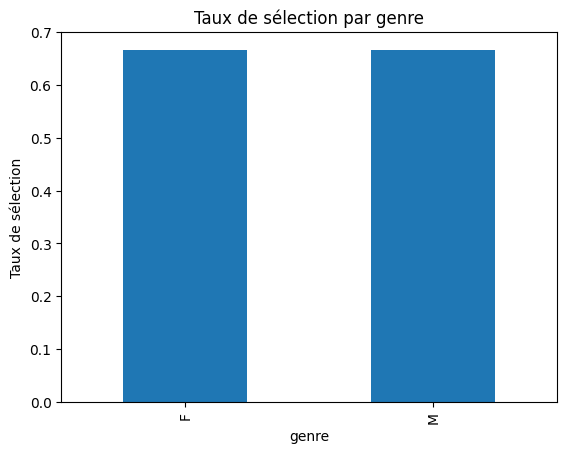

In [43]:
from fairlearn.metrics import MetricFrame, selection_rate

# Ajouter la colonne 'selected' basée sur le seuil
cvs['selected'] = y_pred

# Calculer le taux de sélection par genre
selection_rates = cvs.groupby('genre')['selected'].mean()
print("Taux de sélection par genre :")
print(selection_rates)

# Optionnel : afficher un graphique
import matplotlib.pyplot as plt
selection_rates.plot(kind='bar')
plt.ylabel('Taux de sélection')
plt.title('Taux de sélection par genre')
plt.show()